# EDA y Modelo Baseline (Sprint 1)

Análisis exploratorio, validación de hipótesis de negocio y entrenamiento de regresión logística baseline sin fuga de datos.

## 1. Importación de Librerías

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Make the scripts package importable from this notebook's directory
sys.path.insert(0, str(Path(".").resolve()))

from scripts.config import PROCESSED_DIR
from scripts.model import BASELINE_FEATURES, train_baseline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga de Master Table

In [ ]:
master_table_path = PROCESSED_DIR / "master_table.parquet"

df = pd.read_parquet(master_table_path)
print(f"Master Table cargada con éxito. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

## 3. Estructura y Valores Nulos

In [3]:
print("===== Tipos de datos e Información general =====")
df.info()

print("\n===== Valores Nulos por Columna =====")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
if len(nulls) > 0:
    display(pd.DataFrame({"Nulls Count": nulls, "Proportion": nulls / len(df)}))
else:
    print("No hay valores nulos en el dataset.")

===== Tipos de datos e Información general =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_unique_id           96096 non-null  object        
 1   customer_zip_code_prefix     96096 non-null  int64         
 2   customer_city                96096 non-null  object        
 3   customer_state               96096 non-null  object        
 4   total_orders                 96096 non-null  int64         
 5   total_items                  96096 non-null  float64       
 6   total_products               96096 non-null  float64       
 7   avg_review_score             95380 non-null  float64       
 8   total_reviews                96096 non-null  float64       
 9   first_purchase               96096 non-null  datetime64[ns]
 10  last_purchase                96096 non-null  datetime64[n

,Nulls Count,Proportion
avg_delivery_days,2740,0.028513
avg_ticket,2739,0.028503
avg_order_price,2738,0.028492
avg_freight_value,2738,0.028492
avg_freight_ratio,2738,0.028492
avg_review_score,716,0.007451
main_payment_type,1,0.000010
payment_methods_count,1,0.000010


## 4. Análisis Univariado del Target

===== Distribución de la variable Target (is_premium) =====


,Clientes,Proporción
is_premium,,
0,76874,0.799971
1,19222,0.200029


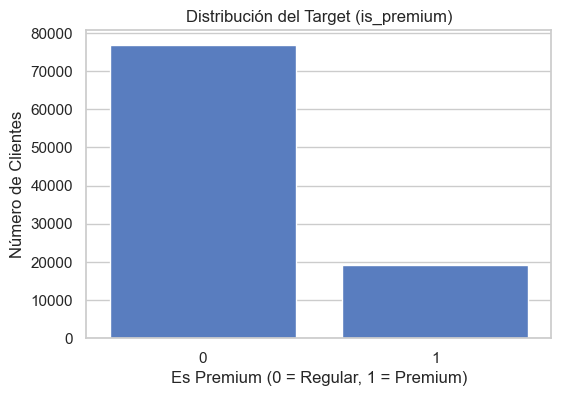

In [4]:
print("===== Distribución de la variable Target (is_premium) =====")
target_counts = df["is_premium"].value_counts()
target_props = df["is_premium"].value_counts(normalize=True)
display(pd.DataFrame({"Clientes": target_counts, "Proporción": target_props}))

# Graficar distribución
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_premium")
plt.title("Distribución del Target (is_premium)")
plt.xlabel("Es Premium (0 = Regular, 1 = Premium)")
plt.ylabel("Número de Clientes")
plt.show()

### Distribución RFM (Recency, Frequency, Monetary)

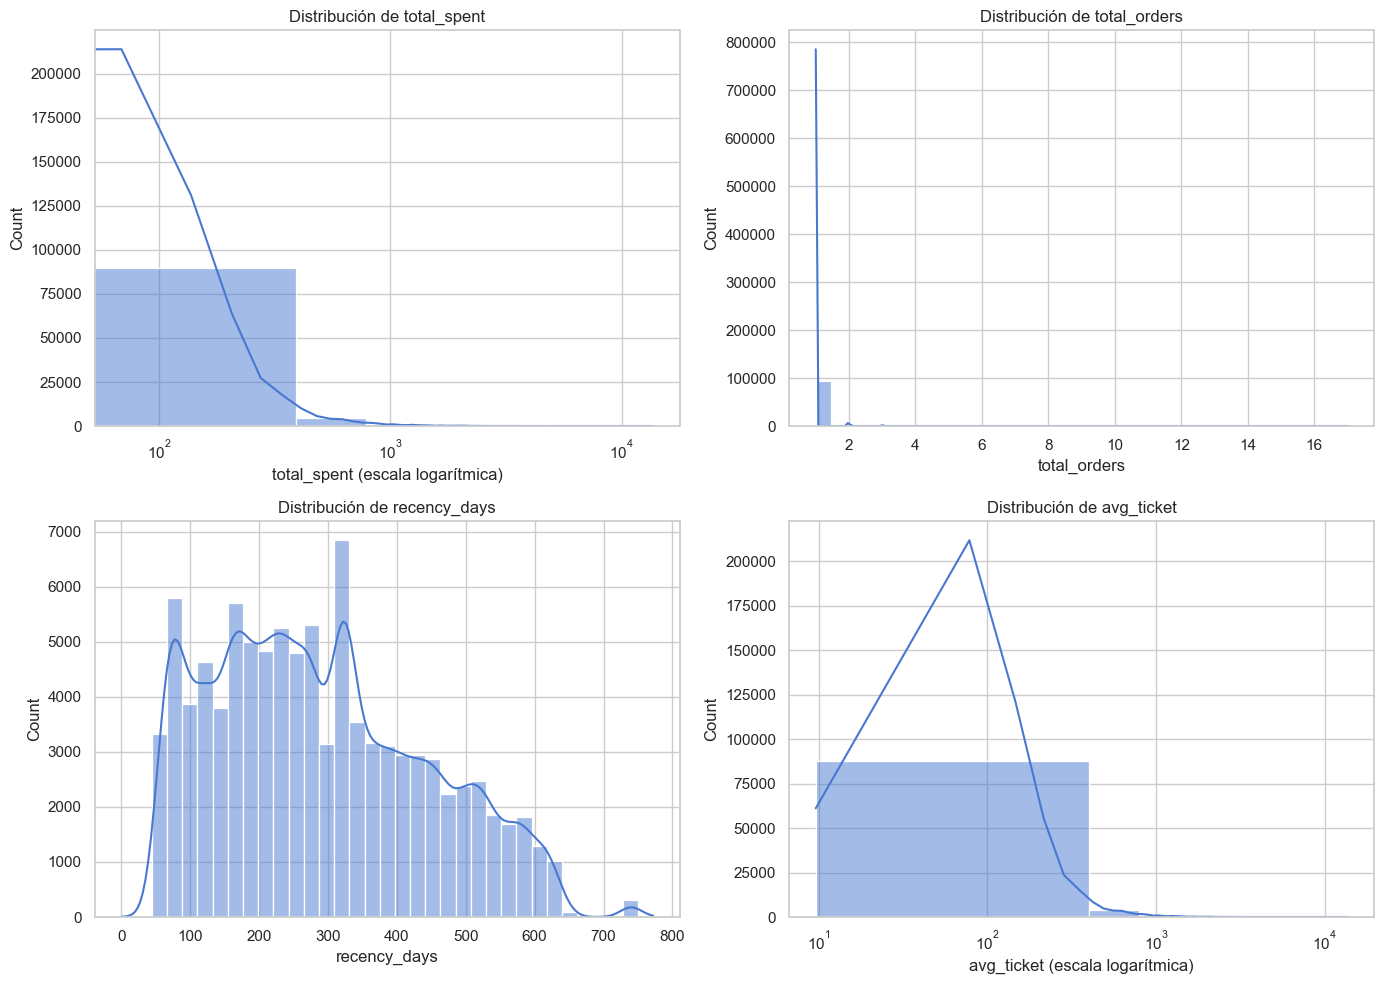

In [5]:
rfm_cols = ["total_spent", "total_orders", "recency_days", "avg_ticket"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(rfm_cols):
    # Evitar log(0)
    data_to_plot = df[col]
    if col in ["total_spent", "avg_ticket"]:
        data_to_plot = data_to_plot[data_to_plot > 0]
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=35)
    axes[i].set_title(f"Distribución de {col}")
    if col in ["total_spent", "avg_ticket"]:
        axes[i].set_xscale("log")
        axes[i].set_xlabel(f"{col} (escala logarítmica)")
plt.tight_layout()
plt.show()

## 5. Análisis Bivariado (Regular vs Premium)

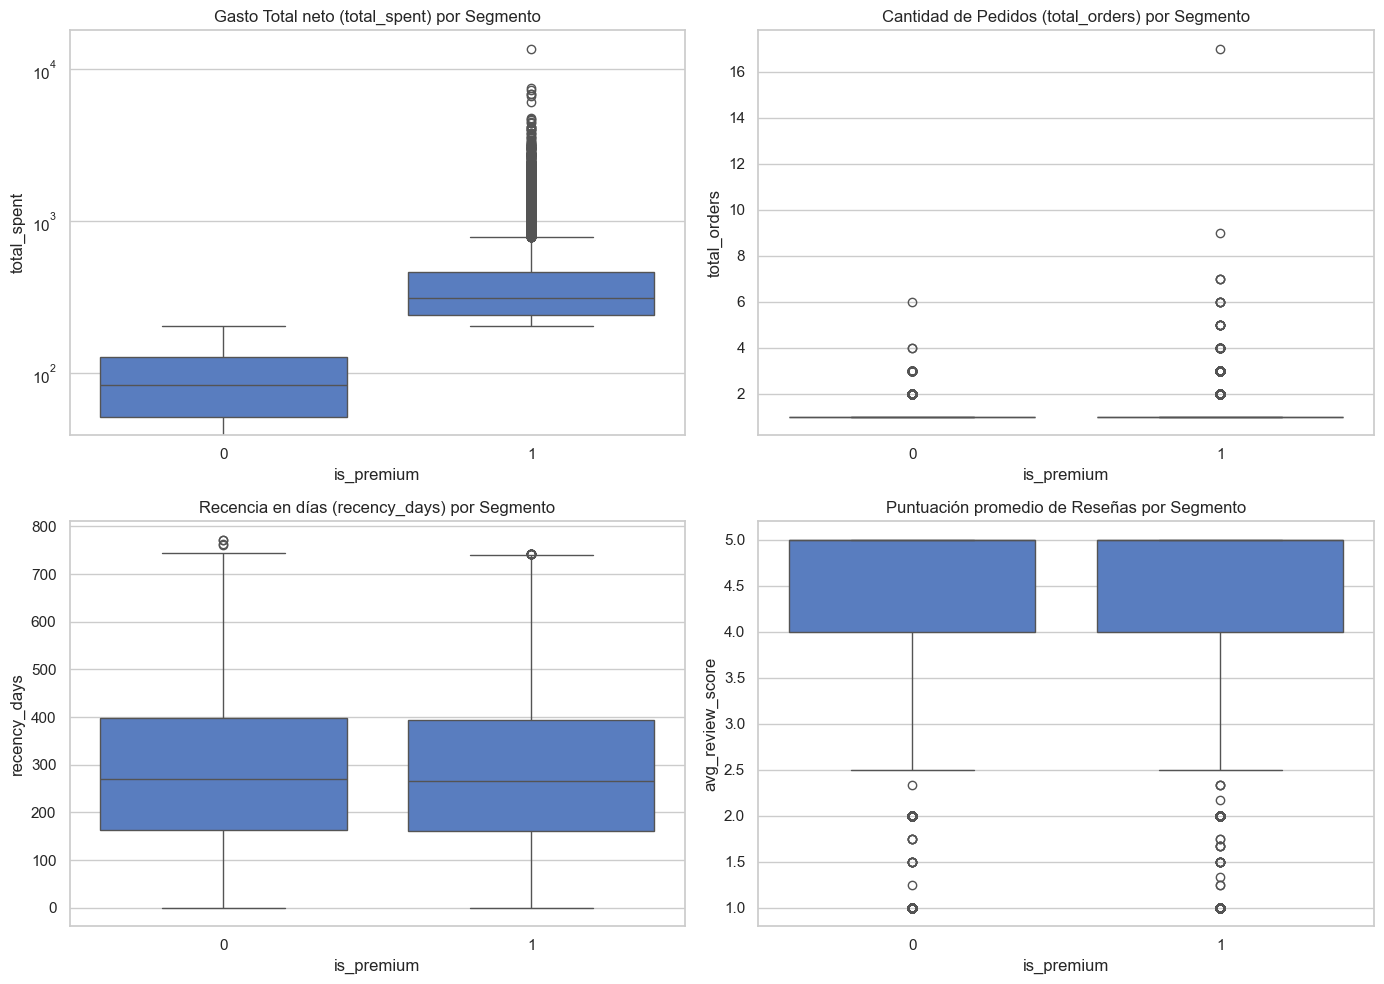

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df, x="is_premium", y="total_spent", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Gasto Total neto (total_spent) por Segmento")

sns.boxplot(data=df, x="is_premium", y="total_orders", ax=axes[1])
axes[1].set_title("Cantidad de Pedidos (total_orders) por Segmento")

sns.boxplot(data=df, x="is_premium", y="recency_days", ax=axes[2])
axes[2].set_title("Recencia en días (recency_days) por Segmento")

sns.boxplot(data=df, x="is_premium", y="avg_review_score", ax=axes[3])
axes[3].set_title("Puntuación promedio de Reseñas por Segmento")

plt.tight_layout()
plt.show()

## 6. Distribución Geográfica del Segmento Premium

C:\Users\marce\AppData\Local\Temp\ipykernel_33892\2653902474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")


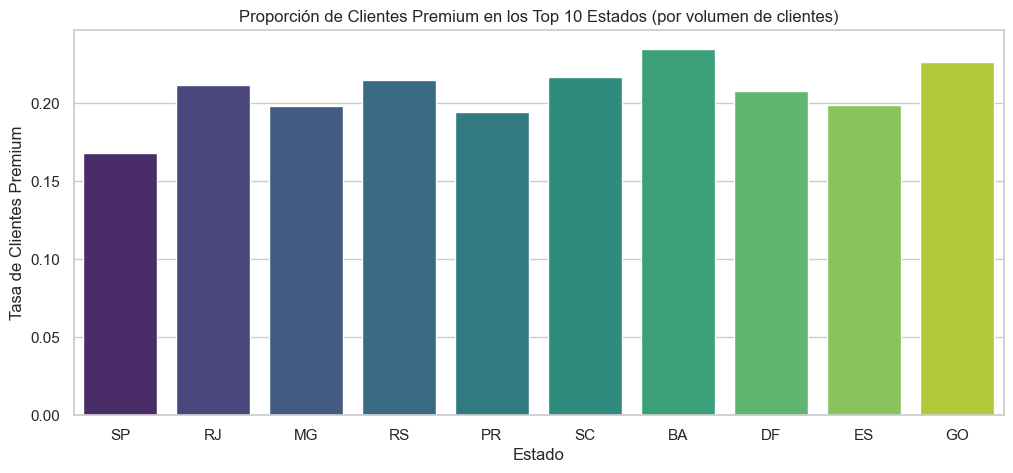

,customer_state,clientes,premium,proporcion_premium
25,SP,40292,6776,0.168172
18,RJ,12383,2621,0.211661
10,MG,11253,2232,0.198347
22,RS,5275,1135,0.215166
17,PR,4878,949,0.194547
23,SC,3532,766,0.216874
4,BA,3276,770,0.235043
6,DF,2073,431,0.207911
7,ES,1964,391,0.199084
8,GO,1950,442,0.226667


In [7]:
state_summary = df.groupby("customer_state").agg(
    clientes=("customer_unique_id", "count"),
    premium=("is_premium", "sum"),
    proporcion_premium=("is_premium", "mean")
).reset_index()

state_summary = state_summary.sort_values(by="clientes", ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")
plt.title("Proporción de Clientes Premium en los Top 10 Estados (por volumen de clientes)")
plt.xlabel("Estado")
plt.ylabel("Tasa de Clientes Premium")
plt.show()

display(state_summary)

## 7. Matriz de Correlación

===== Correlación de Pearson con is_premium =====
is_premium                     1.000000
total_spent                    0.611573
avg_ticket                     0.593267
avg_order_price                0.580356
avg_freight_value              0.393834
total_items                    0.236248
total_products                 0.192890
delivered_orders               0.169287
total_orders                   0.147179
total_reviews                  0.125135
avg_estimated_delivery_days    0.108290
customer_lifetime_days         0.103388
avg_delivery_days              0.073041
customer_zip_code_prefix       0.060665
late_deliveries                0.026645
late_delivery_rate             0.017865
payment_methods_count          0.000474
recency_days                  -0.008337
avg_review_score              -0.015194
canceled_orders               -0.029630
cancellation_rate             -0.034565
avg_freight_ratio             -0.382435
Name: is_premium, dtype: float64


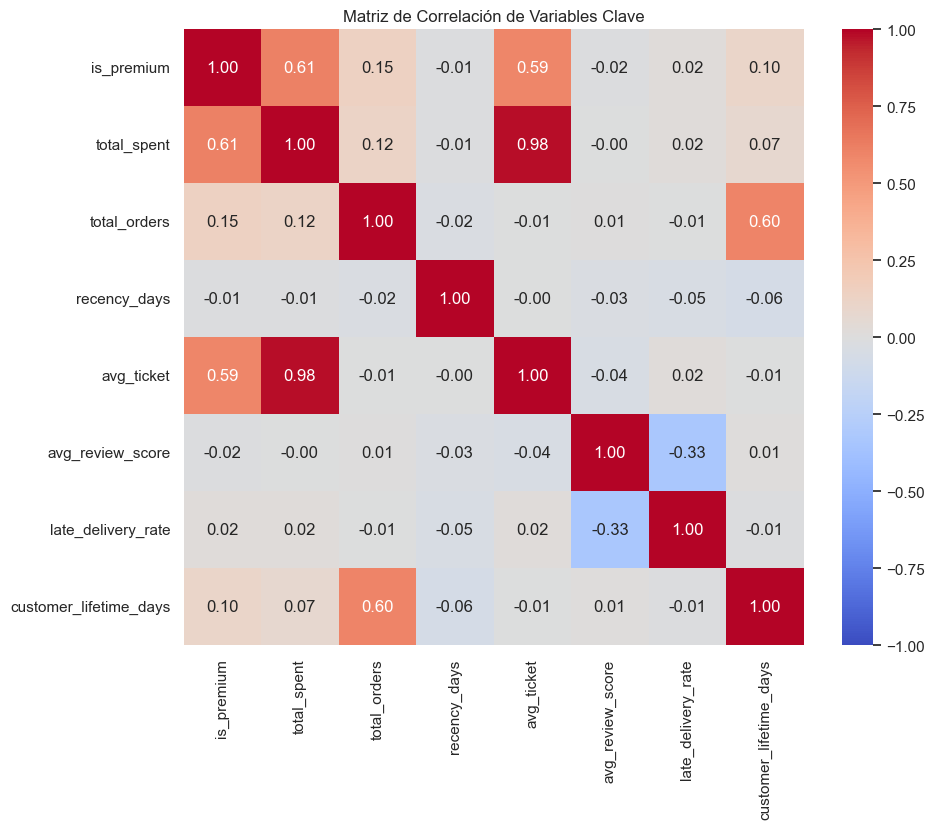

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["is_premium"].sort_values(ascending=False)
print("===== Correlación de Pearson con is_premium =====")
print(correlations)

key_vars = [
    "is_premium", "total_spent", "total_orders", "recency_days", 
    "avg_ticket", "avg_review_score", "late_delivery_rate", "customer_lifetime_days"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[key_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Variables Clave")
plt.show()

## 8. Validación de Hipótesis de Negocio

In [9]:
print("===== Validación Hipótesis 1 (Frecuencia de compra) =====")
display(df.groupby("is_premium")["total_orders"].agg(["mean", "median", "max", "count"]))

print("\n===== Validación Hipótesis 2 (Calificaciones) =====")
display(df.groupby("is_premium")["avg_review_score"].agg(["mean", "median", "std"]))

print("\n===== Validación Hipótesis 3 (Logística y Retrasos) =====")
display(df.groupby("is_premium")["late_delivery_rate"].agg(["mean", "max"]))

print("\n===== Otras comparativas de negocio clave =====")
display(df.groupby("is_premium").agg(
    ticket_medio=("avg_ticket", "mean"),
    dias_lifetime_medio=("customer_lifetime_days", "mean")
))

===== Validación Hipótesis 1 (Frecuencia de compra) =====


,mean,median,max,count
is_premium,,,,
0,1.019031,1.0,6,76874
1,1.097909,1.0,17,19222



===== Validación Hipótesis 2 (Calificaciones) =====


,mean,median,std
is_premium,,,
0,4.095153,5.0,1.333550
1,4.044182,5.0,1.372925



===== Validación Hipótesis 3 (Logística y Retrasos) =====


,mean,max
is_premium,,
0,0.076710,1.0
1,0.088695,1.0



===== Otras comparativas de negocio clave =====


,ticket_medio,dias_lifetime_medio
is_premium,,
0,93.986304,1.398717
1,416.138103,7.961711


### Análisis Operacional:

* **Frecuencia (H1):** La frecuencia promedio es similar (~1.0 vs ~1.1). La diferenciación es monetaria.
* **Satisfacción (H2):** Clientes premium puntúan ligeramente menos (4.04 vs 4.09), indicando mayor nivel de exigencia.
* **Retrasos (H3):** Los clientes premium sufren más demoras (8.87% vs 7.67%), posiblemente debido a la complejidad de envío de artículos caros o voluminosos.

## 9. Modelo Baseline

Entrenamiento de una Regresión Logística simple con split train/test inicial e imputación neutral basada únicamente en entrenamiento.

In [ ]:
results = train_baseline(df)

print(f"Features usadas: {BASELINE_FEATURES}")
print("\n===== REPORTE DE CLASIFICACIÓN (Baseline Logístico) =====")
print(classification_report(results["y_test"], results["y_pred"]))
print(f"ROC-AUC Score: {roc_auc_score(results['y_test'], results['y_proba']):.4f}")

# Confusion matrix
cm = confusion_matrix(results["y_test"], results["y_pred"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Regular", "Premium"], yticklabels=["Regular", "Premium"])
plt.title("Matriz de Confusión - Modelo Baseline")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 10. Conclusiones

* El baseline libre de data leakage establece un **ROC-AUC de 0.5355**.
* La **Paradoja del Target** (compras únicas costosas en el 97% de los usuarios) indica la necesidad de features del catálogo y cuotas en el Sprint 2.